#Categorização de imagens utilizando CNN - Fashion MNIST

Este exemplo utiliza a base de dados Fashion MNIST, que consiste em um conjunto de imagens pertencentes a 10 categorias.

Fonte: https://keras.io/api/datasets/fashion_mnist/

Importante: Para este exemplo será preciso ativar a GPU para diminuir o tempo de processamento.

Para isso, clique em Editar > Configurações de notebook > GPU.

##Etapa 01
Importar as bibliotecas de aprendizado de máquina e computação científica.

In [1]:
#Bibliotecas de aprendizado de máquina
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import MaxPooling2D, AveragePooling2D
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers import Dropout

#Bibliotecas de computação científica
import numpy as np
import matplotlib.pyplot as plt

2026-02-23 10:09:09.161663: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-23 10:09:10.640389: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-23 10:09:14.308847: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


##Etapa 02
Importar a base de dados Fashion MNIST do Keras.

Curiosidade: O Keras fornece um conjunto de base de dados para aprendizado. Veja mais em: https://keras.io/api/datasets/

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

##Etapa 03
Conhecer e plotar a base de dados.

x_train (60000, 28, 28)
y_train (60000,)
x_test (10000, 28, 28)
y_test (10000,)
Classes de imagens:  ['t-shirt/top', 'trouser', 'pullover', 'dress', 'coat', 'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']


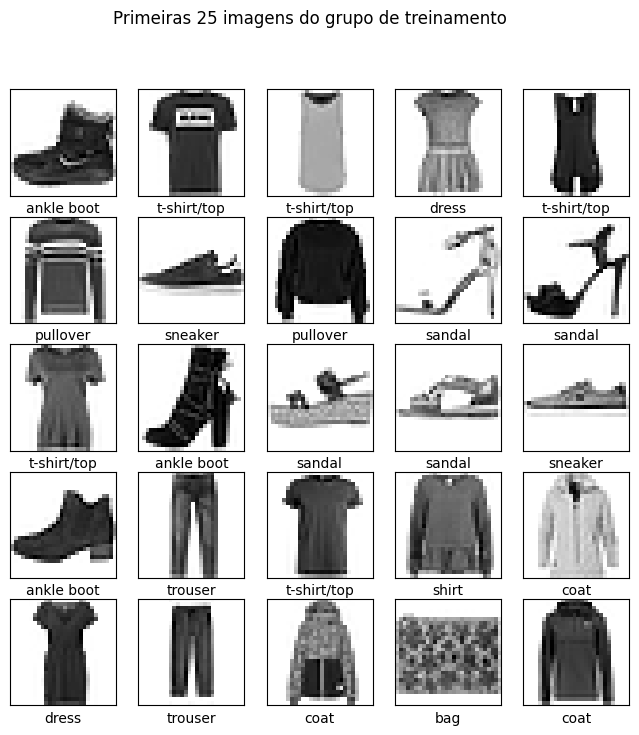

In [3]:
#Nome das categorias:
# Label               Descrição
# 0                   T-shirt/top
# 1                   Trouser
# 2                   Pullover
# 3                   Dress
# 4                   Coat
# 5                   Sandal
# 6                   Shirt
# 7                   Sneaker
# 8                   Bag
# 9                   Ankle boot

#Verificar a quantidade de dados para treinamento e validação
print('x_train', x_train.shape)
print('y_train', y_train.shape)
print('x_test', x_test.shape)
print('y_test', y_test.shape)

#Define uma lista com os nomes das categorias
class_names = ['t-shirt/top', 'trouser', 'pullover', 'dress', 'coat',
               'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']

print('Classes de imagens: ', class_names)

#Plotar imagem
plt.figure(figsize=(8,8))
plt.suptitle('Primeiras 25 imagens do grupo de treinamento')
for i in range(25):
  plt.subplot(5,5,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(x_train[i], cmap=plt.cm.binary)
  plt.xlabel(class_names[y_train[i]])
plt.show()

In [4]:
y_test

array([9, 2, 1, ..., 8, 1, 5], shape=(10000,), dtype=uint8)

In [5]:
x_train[0,:,:]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  

##Etapa 04
Pré-processar as imagens de forma que os valores de intensidade para os pixels fiquem entre 0 e 1 e adicionar uma dimensão a mais em x_train e x_test para que fiquem com 4 dimensões no formato aceito pela CNN.

Formato aceito: (qtd imagens, qtd linhas, qtd colunas, qtd canais)

In [6]:
x_train = x_train / 255
x_test = x_test / 255

In [7]:
x_train.shape

(60000, 28, 28)

In [8]:
x_train = x_train.reshape(x_train.shape[0], x_train.shape[1], x_train.shape[2], 1)
x_test = x_test.reshape(x_test.shape[0], x_test.shape[1], x_test.shape[2], 1)

print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


##Etapa 05
Construir a rede neural utilizando o Keras.

In [ ]:
model = Sequential()
model.add(Conv2D(64, (2,2), activation='relu', input_shape=(28,28,1))),
model.add(MaxPooling2D(2,2)),
model.add(Dropout(0.3)),
model.add(Conv2D(64, (2,2), activation='relu')),
model.add(AveragePooling2D((2,2))),
model.add(Flatten()),
model.add(Dropout(0.5)),
model.add(Dense(64, activation='relu')),
model.add(Dropout(0.1)),
model.add(Dense(10, activation='softmax'))

model.summary()


## Conv 2D always strides in two directions. The third one is fully used, no channel independence

# Second Conv2D: input shape = (13, 13, 64)
# Each filter has size (2, 2, 64) → 2*2*64 = 256 weights
# +1 bias per filter → 256 + 1 = 257 parameters per filter
# 64 filters total → 257 * 64 = 16,448 parameters


# Conv2D params = (kernel_h * kernel_w * input_channels + 1_bias) * num_filters;
# Dense params = (input_units * output_units) + output_units_biases;
# Pooling/Dropout/Flatten = 0 params

/home/Workspace/venv_wsl/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1771852166.973272   29466 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1763 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 27, 27, 64)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 64)     │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 6, 6, 64)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,938 (644.29 KB)

 Trainable params: 164,938 (644.29 KB)

 Non-trainable params: 0 (0.00 B)

##Etapa 06
Compilar o modelo.

Optimizer: As opções são encontradas em https://keras.io/api/optimizers/

Loss: As opções são encontradas em https://keras.io/api/losses/

Metrics: As opções são encontradas em https://keras.io/api/metrics/

In [10]:
optimizer = keras.optimizers.Adam(learning_rate = 0.001)
model.compile(optimizer=optimizer,
            loss='sparse_categorical_crossentropy',
            metrics=['sparse_categorical_accuracy'])

##Etapa 07
Treinar o modelo e realizar a validação.

Epoch 1/100


2026-02-23 10:09:40.359904: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fea20015fb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-23 10:09:40.359967: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2050, Compute Capability 8.6
2026-02-23 10:09:40.502962: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-23 10:09:40.964135: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-02-23 10:09:42.731871: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_903', 120 bytes spill stores, 120 bytes spill loads

2026-02-23 10:09:42.822886: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas

500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 22ms/step - loss: 0.6617 - sparse_categorical_accuracy: 0.7549 - val_loss: 0.4391 - val_sparse_categorical_accuracy: 0.8411
Epoch 2/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.4394 - sparse_categorical_accuracy: 0.8393 - val_loss: 0.3715 - val_sparse_categorical_accuracy: 0.8667
Epoch 3/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.3924 - sparse_categorical_accuracy: 0.8577 - val_loss: 0.3547 - val_sparse_categorical_accuracy: 0.8706
Epoch 4/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.3644 - sparse_categorical_accuracy: 0.8659 - val_loss: 0.3248 - val_sparse_categorical_accuracy: 0.8827
Epoch 5/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.3427 - sparse_categorical_accuracy: 0.8744 - val_loss: 0.3125 - val_sparse_categorical_accuracy: 0.8867
Epoch 6/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.3270 - sparse_categorical_accuracy: 0.8807 - val_loss: 0.3014 - val_sparse_categorical_accuracy: 0.8898
Epo

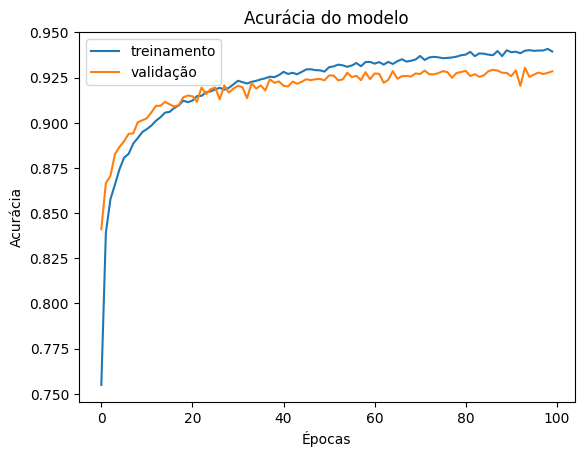

In [ ]:
history = model.fit(x_train, y_train, epochs=100, batch_size= 120, validation_data=(x_test, y_test))

# An epoch = one full pass over the entire training dataset.
# Batch size = number of samples processed before one weight update.
# Steps per epoch = num_samples / batch_size.
# Epochs and batch size are independent hyperparameters.

plt.plot(history.history['sparse_categorical_accuracy'])
plt.plot(history.history['val_sparse_categorical_accuracy'])

# 'sparse_categorical_accuracy' = training accuracy per epoch
# 'val_sparse_categorical_accuracy' = validation accuracy per epoch (computed on validation_data after each epoch)

plt.title('Acurácia do modelo')
plt.ylabel('Acurácia')
plt.xlabel('Épocas')
plt.legend(['treinamento', 'validação'], loc='upper left')
plt.show()



# Training set: used to learn model parameters (e.g., weights via backpropagation in an MLP).
# Validation set: used to tune hyperparameters (e.g., number of hidden units, early stopping)
#                 and to select the best model during development.
# Test set: used only once after the final model is chosen, to estimate true generalization error.
# Important: The validation error is optimistically biased because it was used for model selection.
#            After evaluating on the test set, the model must NOT be tuned any further.

##Etapa 08
Realizar algumas predições. Experimente variar a amostra (variável i).

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


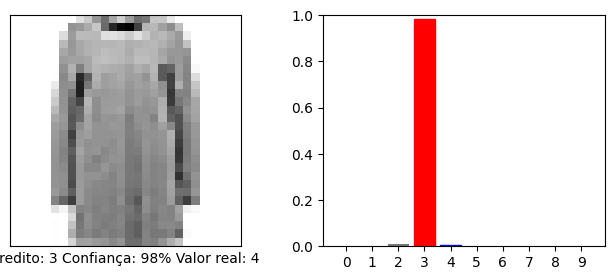

In [19]:
predictions = model.predict(x_test)
i = 150

def plot_image(prediction_array, true_label, img):
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(np.squeeze(img), cmap=plt.cm.binary)
  predicted_label = np.argmax(prediction_array)
  plt.xlabel('Predito: {} Confiança: {:2.0f}% Valor real: {}'.format(predicted_label, 100*np.max(prediction_array), true_label))

def plot_rate(prediction_array, true_label):
  plt.grid(False)
  plt.xticks(range(10))
  thisplot = plt.bar(range(10), prediction_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(prediction_array)
  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')


plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plot_image(predictions[i], y_test[i], x_test[i])
plt.subplot(1,2,2)
plot_rate(predictions[i], y_test[i])
plt.show()

In [13]:
predictions[25]

array([2.1710071e-04, 1.4250542e-10, 4.9252287e-01, 8.1709025e-08,
       1.3048261e-01, 2.2980365e-12, 3.7677729e-01, 7.6224639e-13,
       1.2337271e-09, 4.0216953e-12], dtype=float32)

##Etapa 09
Encontrar todas as predições erradas.

In [14]:
error_classification = []

for i in range(len(predictions)):
  if (np.argmax(predictions[i]) != y_test[i]):
    error_classification.append(i)

print('Total de predições erradas: ', len(error_classification))
print('Lista das predições erradas: ', error_classification)

Total de predições erradas:  715
Lista das predições erradas:  [12, 23, 25, 27, 42, 43, 49, 51, 57, 67, 68, 98, 103, 147, 150, 239, 244, 248, 271, 314, 316, 324, 325, 331, 361, 374, 378, 381, 382, 396, 408, 410, 441, 444, 452, 460, 491, 511, 529, 548, 572, 600, 628, 635, 670, 688, 711, 732, 747, 753, 760, 787, 800, 801, 830, 851, 881, 905, 909, 935, 938, 939, 960, 965, 971, 977, 979, 994, 1000, 1025, 1055, 1101, 1104, 1111, 1129, 1131, 1139, 1142, 1162, 1165, 1174, 1185, 1192, 1197, 1210, 1231, 1249, 1254, 1300, 1305, 1329, 1336, 1408, 1425, 1449, 1455, 1462, 1496, 1509, 1522, 1533, 1572, 1586, 1620, 1626, 1642, 1643, 1645, 1648, 1650, 1659, 1665, 1706, 1731, 1743, 1744, 1771, 1778, 1810, 1848, 1856, 1867, 1879, 1917, 1942, 1943, 1953, 1964, 1968, 1980, 2001, 2006, 2009, 2037, 2067, 2073, 2089, 2106, 2110, 2111, 2144, 2162, 2195, 2236, 2252, 2278, 2281, 2308, 2311, 2318, 2326, 2331, 2336, 2337, 2352, 2355, 2373, 2376, 2396, 2425, 2431, 2457, 2467, 2469, 2476, 2485, 2487, 2500, 2506, 25